In [100]:
#Importation de la librairie pandas
import pandas as pd

In [101]:
#Lecture du fichier CSV
df = pd.read_csv('football.csv')
df.head()

,id,date,home_team,away_team,rank_change_home,rank_change_away,home_goals_mean,home_goals_mean_l5,home_goals_suf_mean,home_goals_suf_mean_l5,...,away_goals_mean,away_goals_mean_l5,away_goals_suf_mean,away_goals_suf_mean_l5,away_rank_mean,away_rank_mean_l5,away_points_mean,away_points_mean_l5,target,match_type
0,2221,2021-09-09,Brazil,Peru,-1.0,-5.0,2.028571,0.8,0.371429,0.4,...,1.027778,1.4,1.583333,1.6,24.388889,21.2,8.16,31.28,0,Friendly
1,507,2019-05-29,Comoros,Mauritius,5.0,NaN,1.166667,1.2,1.666667,1.8,...,1.200000,1.2,1.200000,1.2,159.800000,159.8,-6.00,-6.00,0,Friendly
2,1545,2020-11-18,Serbia,Russia,-1.0,NaN,1.608696,1.2,1.347826,1.2,...,2.136364,0.8,1.045455,1.2,65.681818,62.0,70.00,-5.00,0,Friendly
3,2067,2021-09-01,Senegal,Togo,-1.0,NaN,1.482759,1.4,0.620690,0.8,...,0.857143,0.8,1.214286,1.2,104.500000,82.0,-31.86,-22.86,0,Friendly
4,4448,2024-03-22,Peru,Nicaragua,-2.0,NaN,0.968750,0.2,1.265625,1.6,...,1.600000,3.0,1.244444,0.2,132.200000,169.4,-21.30,23.59,0,Competition


1. ANALYSE EXPLORATOIRE DES DONNEES

In [102]:
#Afficher les differntes colonnes de notre jeu de donnees
df.columns

Index(['id', 'date', 'home_team', 'away_team', 'rank_change_home',
       'rank_change_away', 'home_goals_mean', 'home_goals_mean_l5',
       'home_goals_suf_mean', 'home_goals_suf_mean_l5', 'home_rank_mean',
       'home_rank_mean_l5', 'home_points_mean', 'home_points_mean_l5',
       'away_goals_mean', 'away_goals_mean_l5', 'away_goals_suf_mean',
       'away_goals_suf_mean_l5', 'away_rank_mean', 'away_rank_mean_l5',
       'away_points_mean', 'away_points_mean_l5', 'target', 'match_type'],
      dtype='object')

Text(0.5, 1.0, 'Distribution des buts marqués à domicile')

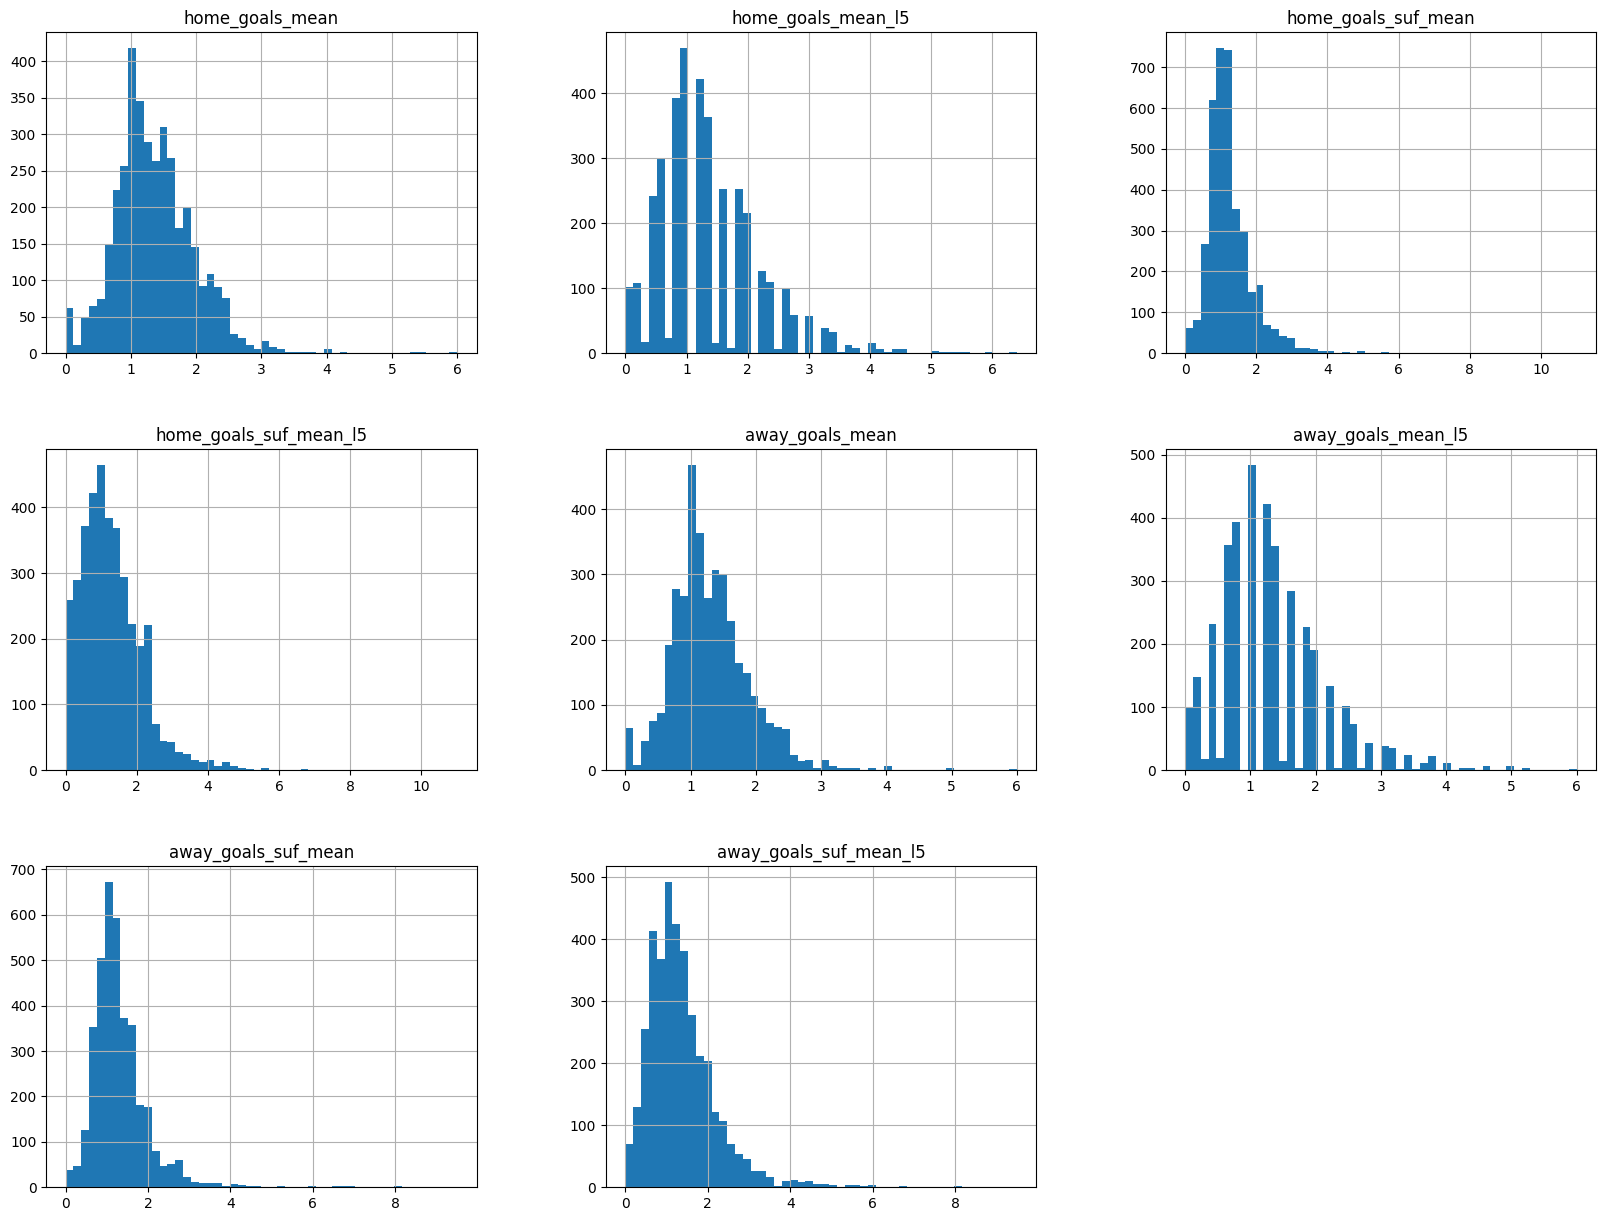

In [103]:
import matplotlib.pyplot as plt

df[['home_goals_mean','home_goals_mean_l5', 'home_goals_suf_mean', 'home_goals_suf_mean_l5', 'away_goals_mean', 'away_goals_mean_l5',
       'away_goals_suf_mean', 'away_goals_suf_mean_l5']].hist(bins=50, figsize=(20,15))
plt.title("Distribution des buts marqués à domicile")

#Affichages des histogrammes de notre jeu de donnees

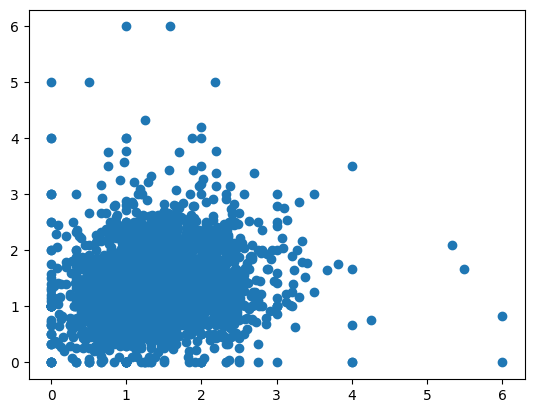

In [104]:
plt.scatter(df['home_goals_mean'], df['away_goals_mean'])
#La plupart des buts marqués par les equipes est generalement entre 0 et 3

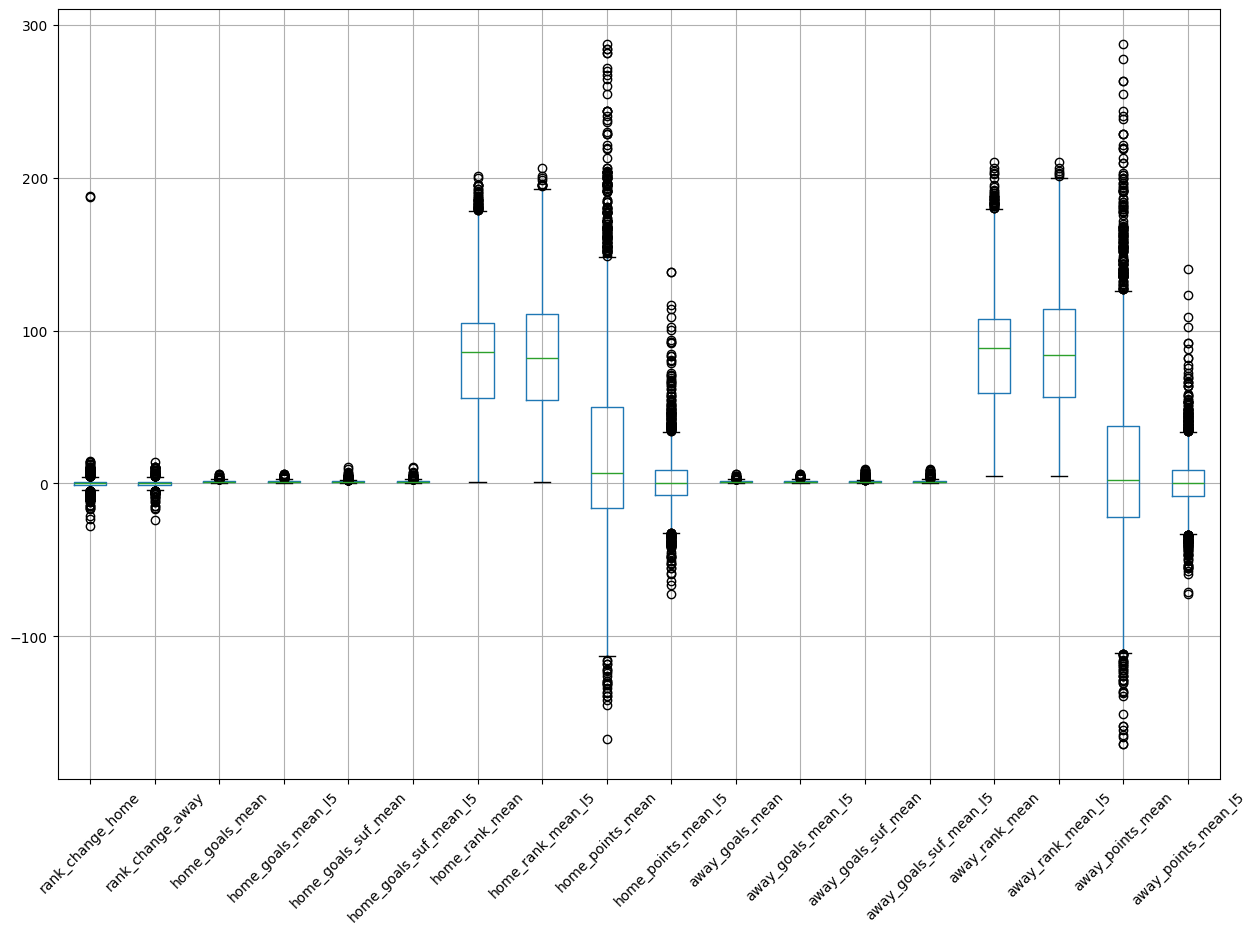

In [105]:
plt.figure(figsize=(15, 10))  # Taille de la figure 
df.boxplot(['rank_change_home',
       'rank_change_away', 'home_goals_mean', 'home_goals_mean_l5',
       'home_goals_suf_mean', 'home_goals_suf_mean_l5', 'home_rank_mean',
       'home_rank_mean_l5', 'home_points_mean', 'home_points_mean_l5',
       'away_goals_mean', 'away_goals_mean_l5', 'away_goals_suf_mean',
       'away_goals_suf_mean_l5', 'away_rank_mean', 'away_rank_mean_l5',
       'away_points_mean', 'away_points_mean_l5'])

plt.xticks(rotation=45)  # Rotation des labels des axes pour qu'ils ne se chevauchent pas

plt.show()

#Suivant ce boxplot, les valeurs aberantes sont les valeurs qui sont en dehors des moustaches
#Nous pouvons voir que les valeurs aberantes sont presentes dans la plupart des colonnes mais celles qui pourraient sont les suivanets:
#'rank_change_home', 'home_points_mean_l5', 'home_points_mean', 'away_points_mean', 'away_points_mean_l5'

In [106]:
#Suppression des valeurs aberantes dans 'rank_change_home'
#df = df[(df['rank_change_home'] <= 150)]

In [107]:
#Traitement des valeurs aberrantes par suppression
colonnes = ['rank_change_home', 'home_points_mean_l5', 'home_points_mean', 'away_points_mean', 'away_points_mean_l5']
Q1 = df[colonnes].quantile(0.25)
Q3 = df[colonnes].quantile(0.75)
IQR = Q3 - Q1

minimum = Q1 - 1.5*IQR
maximum = Q3 + 1.5*IQR

for col in colonnes:
    df = df[(df[col] >= minimum[col]) & (df[col] <= maximum[col])]
df.head()

,id,date,home_team,away_team,rank_change_home,rank_change_away,home_goals_mean,home_goals_mean_l5,home_goals_suf_mean,home_goals_suf_mean_l5,...,away_goals_mean,away_goals_mean_l5,away_goals_suf_mean,away_goals_suf_mean_l5,away_rank_mean,away_rank_mean_l5,away_points_mean,away_points_mean_l5,target,match_type
2,1545,2020-11-18,Serbia,Russia,-1.0,NaN,1.608696,1.2,1.347826,1.2,...,2.136364,0.8,1.045455,1.2,65.681818,62.0,70.00,-5.00,0,Friendly
3,2067,2021-09-01,Senegal,Togo,-1.0,NaN,1.482759,1.4,0.620690,0.8,...,0.857143,0.8,1.214286,1.2,104.500000,82.0,-31.86,-22.86,0,Friendly
4,4448,2024-03-22,Peru,Nicaragua,-2.0,NaN,0.968750,0.2,1.265625,1.6,...,1.600000,3.0,1.244444,0.2,132.200000,169.4,-21.30,23.59,0,Competition
5,2346,2021-10-12,Albania,Poland,-3.0,NaN,1.258065,1.6,1.064516,0.8,...,1.914286,3.8,1.028571,1.2,54.571429,102.0,-6.18,-18.05,1,Friendly
6,838,2019-09-07,Serbia,Portugal,1.0,1.0,1.700000,2.0,1.200000,1.8,...,1.400000,1.2,0.700000,0.6,20.700000,21.2,8.00,-9.00,1,Friendly


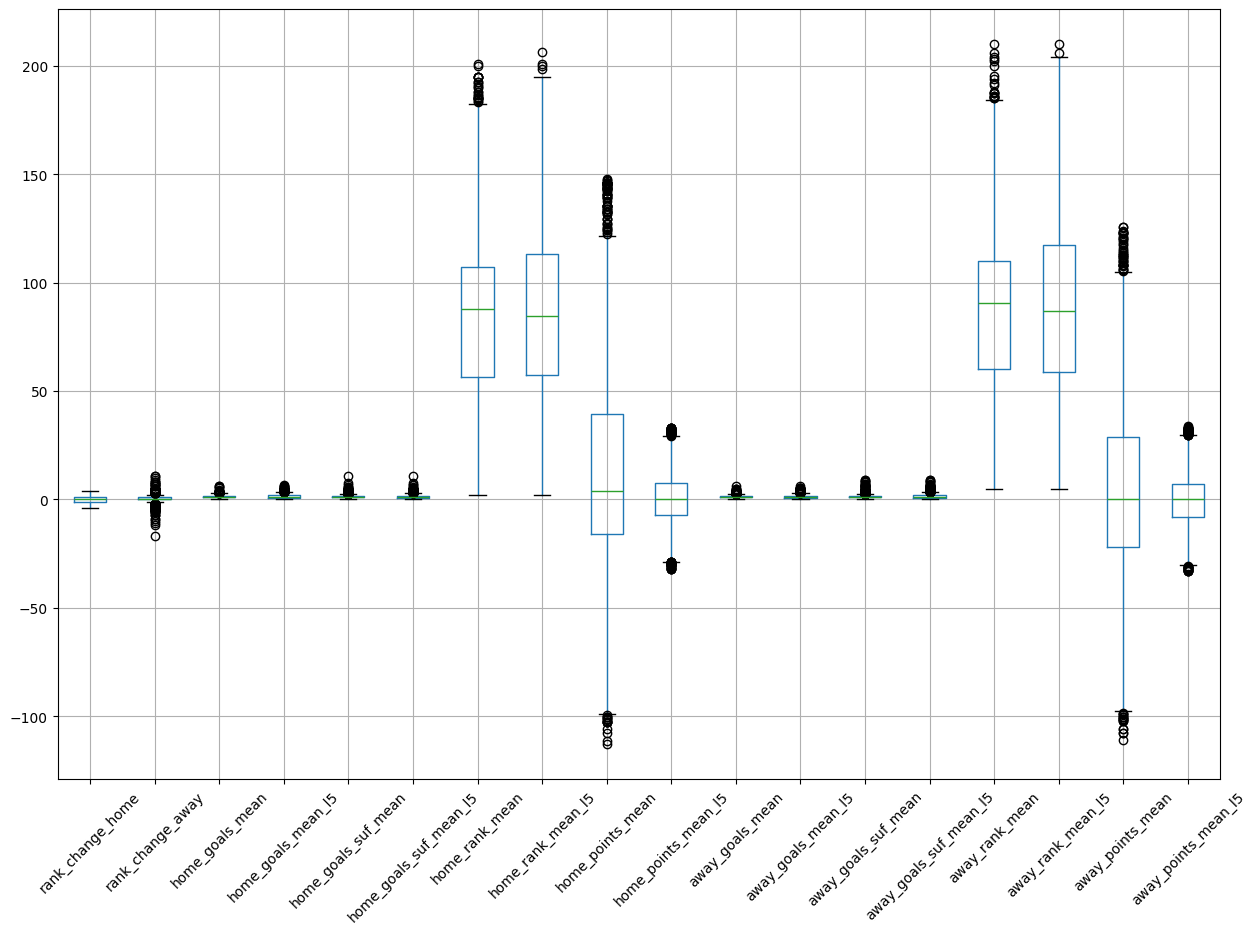

In [108]:
#Affichage des boxplot apres traitement des valeurs aberantes

plt.figure(figsize=(15, 10))  # Taille de la figure 
df.boxplot(['rank_change_home',
       'rank_change_away', 'home_goals_mean', 'home_goals_mean_l5',
       'home_goals_suf_mean', 'home_goals_suf_mean_l5', 'home_rank_mean',
       'home_rank_mean_l5', 'home_points_mean', 'home_points_mean_l5',
       'away_goals_mean', 'away_goals_mean_l5', 'away_goals_suf_mean',
       'away_goals_suf_mean_l5', 'away_rank_mean', 'away_rank_mean_l5',
       'away_points_mean', 'away_points_mean_l5'])

plt.xticks(rotation=45)  # Rotation des labels des axes pour qu'ils ne se chevauchent pas

plt.show()

In [109]:
#Afficher les colonnes numeriques
colonnes_numeriques = df.select_dtypes(include=['int64', 'float']).columns
colonnes_numeriques

Index(['id', 'rank_change_home', 'rank_change_away', 'home_goals_mean',
       'home_goals_mean_l5', 'home_goals_suf_mean', 'home_goals_suf_mean_l5',
       'home_rank_mean', 'home_rank_mean_l5', 'home_points_mean',
       'home_points_mean_l5', 'away_goals_mean', 'away_goals_mean_l5',
       'away_goals_suf_mean', 'away_goals_suf_mean_l5', 'away_rank_mean',
       'away_rank_mean_l5', 'away_points_mean', 'away_points_mean_l5',
       'target'],
      dtype='object')

<Axes: >

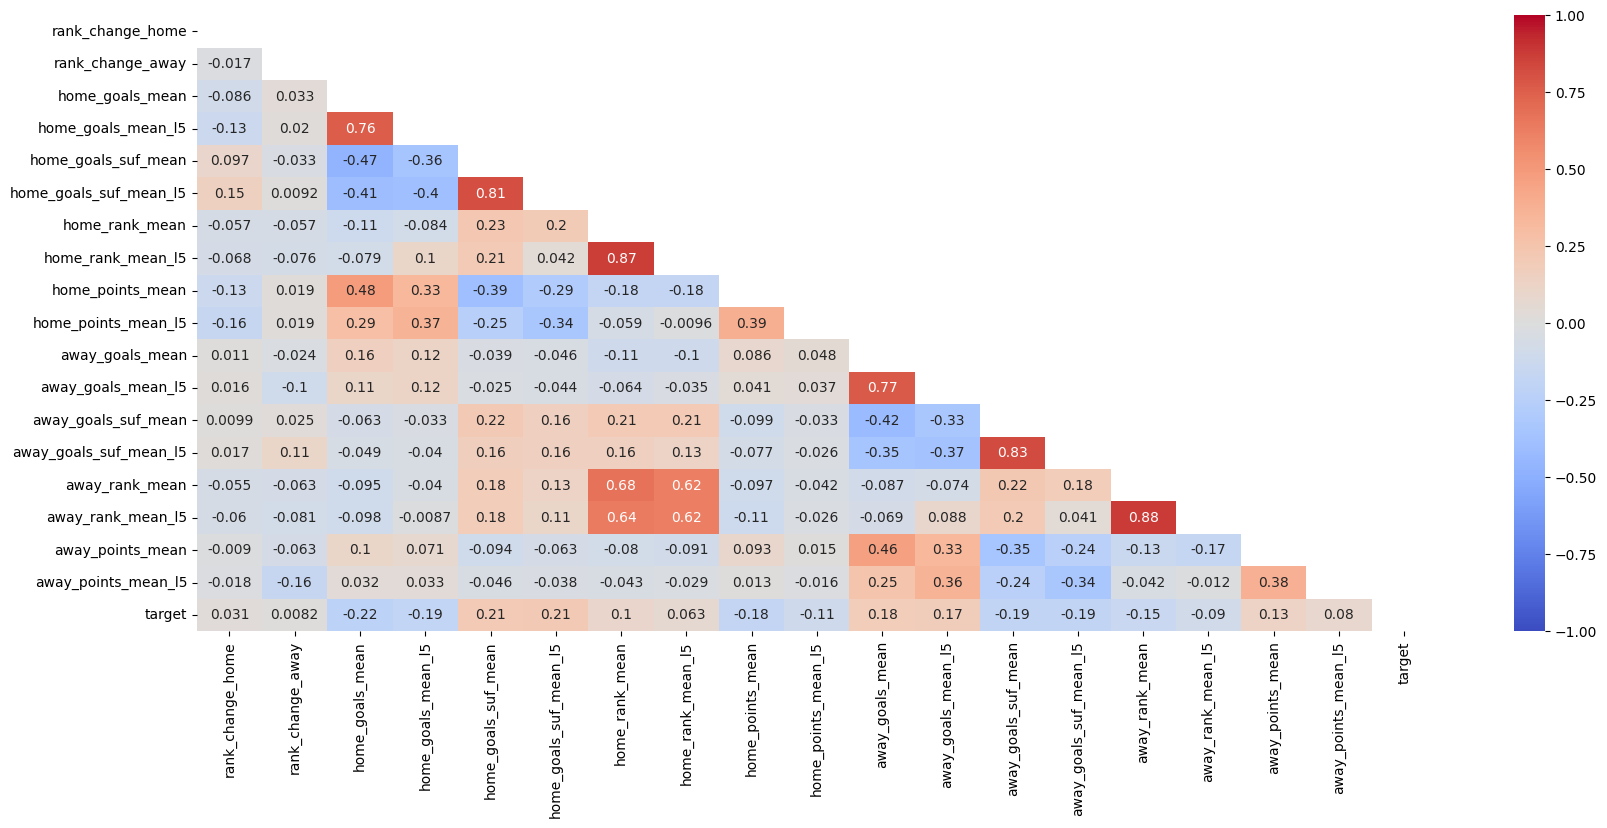

In [110]:
import seaborn as sns
import numpy as np

matrice = df[['rank_change_home','rank_change_away', 'home_goals_mean', 'home_goals_mean_l5',
'home_goals_suf_mean', 'home_goals_suf_mean_l5', 'home_rank_mean',
'home_rank_mean_l5', 'home_points_mean', 'home_points_mean_l5',
'away_goals_mean', 'away_goals_mean_l5', 'away_goals_suf_mean',
'away_goals_suf_mean_l5', 'away_rank_mean', 'away_rank_mean_l5',
'away_points_mean', 'away_points_mean_l5', 'target']].corr()
plt.figure(figsize=(20,8))
sns.heatmap(matrice, vmin=-1, vmax=+1, annot=True, cmap='coolwarm', mask=np.triu(matrice))

# Nous constatons une forte correlation positive entre la moyenne de buts marques par l'equipe a l'exterieur pendant les matchs precedents et celle des 5 derniers matchs
#Le meme cas pour l'equipe a domicile
#Aussi une forte correlation positive entre la moyenne des buts subis par l'equpe a domicile pendant les matchs precedents et celle des 5 derniers matchs
#Meme cas pour l'equipe a domicile

In [111]:
#Afficher le type de chaque colonne
df.dtypes

id                          int64
date                       object
home_team                  object
away_team                  object
rank_change_home          float64
rank_change_away          float64
home_goals_mean           float64
home_goals_mean_l5        float64
home_goals_suf_mean       float64
home_goals_suf_mean_l5    float64
home_rank_mean            float64
home_rank_mean_l5         float64
home_points_mean          float64
home_points_mean_l5       float64
away_goals_mean           float64
away_goals_mean_l5        float64
away_goals_suf_mean       float64
away_goals_suf_mean_l5    float64
away_rank_mean            float64
away_rank_mean_l5         float64
away_points_mean          float64
away_points_mean_l5       float64
target                      int64
match_type                 object
dtype: object

In [112]:
df.info()
#3775 echantillons et 23 caracteristiques

<class 'pandas.core.frame.DataFrame'>
Index: 2912 entries, 2 to 3775
Data columns (total 24 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   id                      2912 non-null   int64  
 1   date                    2912 non-null   object 
 2   home_team               2912 non-null   object 
 3   away_team               2912 non-null   object 
 4   rank_change_home        2912 non-null   float64
 5   rank_change_away        1342 non-null   float64
 6   home_goals_mean         2912 non-null   float64
 7   home_goals_mean_l5      2912 non-null   float64
 8   home_goals_suf_mean     2894 non-null   float64
 9   home_goals_suf_mean_l5  2912 non-null   float64
 10  home_rank_mean          2912 non-null   float64
 11  home_rank_mean_l5       2912 non-null   float64
 12  home_points_mean        2912 non-null   float64
 13  home_points_mean_l5     2912 non-null   float64
 14  away_goals_mean         2912 non-null   float

In [113]:
#Afficher les valeurs uniques
df.nunique()

id                        2912
date                       599
home_team                  195
away_team                  195
rank_change_home             9
rank_change_away            24
home_goals_mean           1104
home_goals_mean_l5          49
home_goals_suf_mean       1062
home_goals_suf_mean_l5      54
home_rank_mean            2647
home_rank_mean_l5          913
home_points_mean          1327
home_points_mean_l5       1295
away_goals_mean           1010
away_goals_mean_l5          44
away_goals_suf_mean       1023
away_goals_suf_mean_l5      62
away_rank_mean            2631
away_rank_mean_l5          928
away_points_mean          1355
away_points_mean_l5       1323
target                       2
match_type                   2
dtype: int64

In [114]:
#Identifier les valeurs manquantes
df.isnull().sum()

id                           0
date                         0
home_team                    0
away_team                    0
rank_change_home             0
rank_change_away          1570
home_goals_mean              0
home_goals_mean_l5           0
home_goals_suf_mean         18
home_goals_suf_mean_l5       0
home_rank_mean               0
home_rank_mean_l5            0
home_points_mean             0
home_points_mean_l5          0
away_goals_mean              0
away_goals_mean_l5           0
away_goals_suf_mean         14
away_goals_suf_mean_l5       0
away_rank_mean               0
away_rank_mean_l5            0
away_points_mean             0
away_points_mean_l5          0
target                       0
match_type                   0
dtype: int64

In [115]:
#Afficher les donnees statistiques des caracteristiques
df.describe()

,id,rank_change_home,rank_change_away,home_goals_mean,home_goals_mean_l5,home_goals_suf_mean,home_goals_suf_mean_l5,home_rank_mean,home_rank_mean_l5,home_points_mean,home_points_mean_l5,away_goals_mean,away_goals_mean_l5,away_goals_suf_mean,away_goals_suf_mean_l5,away_rank_mean,away_rank_mean_l5,away_points_mean,away_points_mean_l5,target
count,2912.000000,2912.000000,1342.000000,2912.000000,2912.000000,2894.000000,2912.000000,2912.000000,2912.000000,2912.000000,2912.000000,2912.000000,2912.000000,2898.000000,2912.000000,2912.000000,2912.000000,2912.000000,2912.000000,2912.000000
mean,2218.595124,-0.007555,0.050671,1.336476,1.342216,1.269485,1.300921,87.449808,87.212179,11.786281,0.284808,1.273828,1.280277,1.345309,1.357973,89.987188,89.438193,3.201985,-0.206298,0.518201
std,1341.518350,1.527019,2.059980,0.607603,0.834081,0.689188,0.865304,36.991831,40.757078,48.583553,12.220831,0.595888,0.802540,0.751280,0.917535,37.046081,41.201930,43.419190,12.653229,0.499754
min,0.000000,-4.000000,-17.000000,0.000000,0.000000,0.000000,0.000000,2.000000,2.000000,-112.850000,-32.000000,0.000000,0.000000,0.000000,0.000000,4.750000,4.750000,-110.990000,-33.240000,0.000000
25%,1080.000000,-1.000000,0.000000,0.970249,0.800000,0.872340,0.800000,56.402574,57.200000,-16.000000,-7.000000,0.901829,0.800000,0.933696,0.800000,60.129076,58.750000,-22.000000,-8.000000,0.000000
50%,2131.500000,0.000000,0.000000,1.250000,1.200000,1.139535,1.200000,87.928922,84.400000,4.000000,0.000000,1.187500,1.200000,1.200000,1.200000,90.668192,86.900000,0.000000,0.000000,1.000000
75%,3345.500000,1.000000,1.000000,1.666667,1.800000,1.525987,1.616667,107.000000,113.200000,39.362500,7.530000,1.571429,1.600000,1.600000,1.800000,109.872174,117.400000,28.902500,7.027500,1.000000
max,4719.000000,4.000000,11.000000,6.000000,6.400000,11.000000,11.000000,201.000000,206.200000,147.950000,33.000000,6.000000,6.000000,9.000000,9.000000,210.000000,210.000000,125.720000,33.910000,1.000000


2. PRE-TRAITEMENT DES DONNEES

In [116]:
#Les colonnes a supprimer : id, home_team, away_team
df = df.drop(columns=["id", "home_team", "away_team"])
df.head()

,date,rank_change_home,rank_change_away,home_goals_mean,home_goals_mean_l5,home_goals_suf_mean,home_goals_suf_mean_l5,home_rank_mean,home_rank_mean_l5,home_points_mean,...,away_goals_mean,away_goals_mean_l5,away_goals_suf_mean,away_goals_suf_mean_l5,away_rank_mean,away_rank_mean_l5,away_points_mean,away_points_mean_l5,target,match_type
2,2020-11-18,-1.0,NaN,1.608696,1.2,1.347826,1.2,54.130435,44.0,30.00,...,2.136364,0.8,1.045455,1.2,65.681818,62.0,70.00,-5.00,0,Friendly
3,2021-09-01,-1.0,NaN,1.482759,1.4,0.620690,0.8,97.551724,113.6,44.45,...,0.857143,0.8,1.214286,1.2,104.500000,82.0,-31.86,-22.86,0,Friendly
4,2024-03-22,-2.0,NaN,0.968750,0.2,1.265625,1.6,31.531250,34.8,-2.43,...,1.600000,3.0,1.244444,0.2,132.200000,169.4,-21.30,23.59,0,Competition
5,2021-10-12,-3.0,NaN,1.258065,1.6,1.064516,0.8,85.548387,66.0,-15.27,...,1.914286,3.8,1.028571,1.2,54.571429,102.0,-6.18,-18.05,1,Friendly
6,2019-09-07,1.0,1.0,1.700000,2.0,1.200000,1.8,57.200000,62.0,25.00,...,1.400000,1.2,0.700000,0.6,20.700000,21.2,8.00,-9.00,1,Friendly


In [117]:
# Transformation de la date
df["year"] = pd.to_datetime(df["date"]).dt.year
df["month"] = pd.to_datetime(df["date"]).dt.month
df["day"] = pd.to_datetime(df["date"]).dt.day
df = df.drop(columns=["date"])
df.head()

,rank_change_home,rank_change_away,home_goals_mean,home_goals_mean_l5,home_goals_suf_mean,home_goals_suf_mean_l5,home_rank_mean,home_rank_mean_l5,home_points_mean,home_points_mean_l5,...,away_goals_suf_mean_l5,away_rank_mean,away_rank_mean_l5,away_points_mean,away_points_mean_l5,target,match_type,year,month,day
2,-1.0,NaN,1.608696,1.2,1.347826,1.2,54.130435,44.0,30.00,3.00,...,1.2,65.681818,62.0,70.00,-5.00,0,Friendly,2020,11,18
3,-1.0,NaN,1.482759,1.4,0.620690,0.8,97.551724,113.6,44.45,0.00,...,1.2,104.500000,82.0,-31.86,-22.86,0,Friendly,2021,9,1
4,-2.0,NaN,0.968750,0.2,1.265625,1.6,31.531250,34.8,-2.43,-28.63,...,0.2,132.200000,169.4,-21.30,23.59,0,Competition,2024,3,22
5,-3.0,NaN,1.258065,1.6,1.064516,0.8,85.548387,66.0,-15.27,6.64,...,1.2,54.571429,102.0,-6.18,-18.05,1,Friendly,2021,10,12
6,1.0,1.0,1.700000,2.0,1.200000,1.8,57.200000,62.0,25.00,13.00,...,0.6,20.700000,21.2,8.00,-9.00,1,Friendly,2019,9,7


In [118]:
#Encodage des donnees categorielles
df = pd.get_dummies(df,columns=['match_type'])
df.head()

,rank_change_home,rank_change_away,home_goals_mean,home_goals_mean_l5,home_goals_suf_mean,home_goals_suf_mean_l5,home_rank_mean,home_rank_mean_l5,home_points_mean,home_points_mean_l5,...,away_rank_mean,away_rank_mean_l5,away_points_mean,away_points_mean_l5,target,year,month,day,match_type_Competition,match_type_Friendly
2,-1.0,NaN,1.608696,1.2,1.347826,1.2,54.130435,44.0,30.00,3.00,...,65.681818,62.0,70.00,-5.00,0,2020,11,18,False,True
3,-1.0,NaN,1.482759,1.4,0.620690,0.8,97.551724,113.6,44.45,0.00,...,104.500000,82.0,-31.86,-22.86,0,2021,9,1,False,True
4,-2.0,NaN,0.968750,0.2,1.265625,1.6,31.531250,34.8,-2.43,-28.63,...,132.200000,169.4,-21.30,23.59,0,2024,3,22,True,False
5,-3.0,NaN,1.258065,1.6,1.064516,0.8,85.548387,66.0,-15.27,6.64,...,54.571429,102.0,-6.18,-18.05,1,2021,10,12,False,True
6,1.0,1.0,1.700000,2.0,1.200000,1.8,57.200000,62.0,25.00,13.00,...,20.700000,21.2,8.00,-9.00,1,2019,9,7,False,True


In [119]:
# Remplacer les valeurs manquantes par la médiane
df['rank_change_away'] = df['rank_change_away'].fillna(df['rank_change_away'].median())
df['home_goals_suf_mean'] = df['home_goals_suf_mean'].fillna(df['home_goals_suf_mean'].median())
df['away_goals_suf_mean'] = df['away_goals_suf_mean'].fillna(df['away_goals_suf_mean'].median())
df['home_points_mean'] = df['home_points_mean'].fillna(df['home_points_mean'].median())
df.head()

,rank_change_home,rank_change_away,home_goals_mean,home_goals_mean_l5,home_goals_suf_mean,home_goals_suf_mean_l5,home_rank_mean,home_rank_mean_l5,home_points_mean,home_points_mean_l5,...,away_rank_mean,away_rank_mean_l5,away_points_mean,away_points_mean_l5,target,year,month,day,match_type_Competition,match_type_Friendly
2,-1.0,0.0,1.608696,1.2,1.347826,1.2,54.130435,44.0,30.00,3.00,...,65.681818,62.0,70.00,-5.00,0,2020,11,18,False,True
3,-1.0,0.0,1.482759,1.4,0.620690,0.8,97.551724,113.6,44.45,0.00,...,104.500000,82.0,-31.86,-22.86,0,2021,9,1,False,True
4,-2.0,0.0,0.968750,0.2,1.265625,1.6,31.531250,34.8,-2.43,-28.63,...,132.200000,169.4,-21.30,23.59,0,2024,3,22,True,False
5,-3.0,0.0,1.258065,1.6,1.064516,0.8,85.548387,66.0,-15.27,6.64,...,54.571429,102.0,-6.18,-18.05,1,2021,10,12,False,True
6,1.0,1.0,1.700000,2.0,1.200000,1.8,57.200000,62.0,25.00,13.00,...,20.700000,21.2,8.00,-9.00,1,2019,9,7,False,True


In [120]:
#Verifier s'il y a des valeurs manquantes
print(df.isnull().sum())

rank_change_home          0
rank_change_away          0
home_goals_mean           0
home_goals_mean_l5        0
home_goals_suf_mean       0
home_goals_suf_mean_l5    0
home_rank_mean            0
home_rank_mean_l5         0
home_points_mean          0
home_points_mean_l5       0
away_goals_mean           0
away_goals_mean_l5        0
away_goals_suf_mean       0
away_goals_suf_mean_l5    0
away_rank_mean            0
away_rank_mean_l5         0
away_points_mean          0
away_points_mean_l5       0
target                    0
year                      0
month                     0
day                       0
match_type_Competition    0
match_type_Friendly       0
dtype: int64


In [121]:
#Identification des classes
df['target'].value_counts()

target
1    1509
0    1403
Name: count, dtype: int64

In [122]:
#Voir la proportion des classes
df['target'].value_counts(normalize=True)

target
1    0.518201
0    0.481799
Name: proportion, dtype: float64

In [123]:
from sklearn.model_selection import train_test_split

In [124]:
train, test = train_test_split(df, random_state=42)

In [125]:
train['target'].value_counts()

target
1    1152
0    1032
Name: count, dtype: int64

In [126]:
test['target'].value_counts()

target
0    371
1    357
Name: count, dtype: int64

In [127]:
train, test = train_test_split(df,random_state=42, stratify=df['target'])

In [128]:
train['target'].value_counts()

target
1    1132
0    1052
Name: count, dtype: int64

In [129]:
test['target'].value_counts()

target
1    377
0    351
Name: count, dtype: int64

In [130]:
#Apres les analyses precedentes sur les classe, nous pouvons dire que les classes sont bien reparties
#Donc on peut conclure que notre jeu de donnees est bien equilibre

3. DEVELOPPEMENT DES MODELES ET EXPERIMENTATION

In [131]:
from sklearn.model_selection import train_test_split 

#Separation des donnees avant la normalisation pour eviter les fuites des donnees
X = df.drop(columns=['target'])
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2, random_state=42)


In [132]:
#Standardiser les caracteristiques

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(X_train)
X_train = scaler.transform(X_train)  # Calculé uniquement sur l'entraînement
X_test = scaler.transform(X_test)  # Appliqué sur le test

In [133]:
#Importation des modeles
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

#Importation des mesures de performances
from sklearn.metrics import accuracy_score


In [134]:
# Initialisation des modèles
models = {
    "Regression" : LogisticRegression(random_state=42),
    "SVM": SVC(random_state=42),
    "KNN": KNeighborsClassifier(),
   "RFC" : RandomForestClassifier(random_state=42)
}

In [135]:
# Entraînement et évaluation
results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    score = model.score(X_test, y_test)
   
    # #Metriques d'evaluations
    accuracy = accuracy_score(y_test, y_pred)
    results[name] = {"Accuracy" : accuracy}


In [136]:
#Affichage des performances
for model, score in results.items():
    print(f"{model}:\n Accuracy = {score['Accuracy']:.4f} ")

Regression:
 Accuracy = 0.7290 
SVM:
 Accuracy = 0.6947 
KNN:
 Accuracy = 0.6278 
RFC:
 Accuracy = 0.7221 


In [137]:
#Ajustement des hyperparametres du modele KNN
k = [1, 50, 200, 300]
for i in k:
    knn = KNeighborsClassifier(n_neighbors=i)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    print(f'k = {i}')
    print(f'Accuracy : {accuracy: .4f}')

#Nous constatons que le modele KNN avec k=200 donne la meilleure performance de 0.7067
   

k = 1
Accuracy :  0.5969
k = 50
Accuracy :  0.7033
k = 200
Accuracy :  0.7067
k = 300
Accuracy :  0.6964


In [138]:
#Ajustement des hyperparametres du modele SVM
C = [0.1, 0.2, 0.5, 1]
kernel = ['linear', 'rbf']
for i in C:
    for j in kernel:
        svm = SVC(kernel=j, C=i)
        svm.fit(X_train, y_train)
        y_pred = svm.predict(X_test)

        accuracy = accuracy_score(y_test, y_pred)
        print(f'C = {i}\nKernel = {j}')
        print(f'Accuracy : {accuracy: .4f}')

#Nous constatons que le modele SVM avec C=0.2 et kernel=linear donne la meilleure performance de 0.7410

C = 0.1
Kernel = linear
Accuracy :  0.7307
C = 0.1
Kernel = rbf
Accuracy :  0.7136
C = 0.2
Kernel = linear
Accuracy :  0.7410
C = 0.2
Kernel = rbf
Accuracy :  0.7273
C = 0.5
Kernel = linear
Accuracy :  0.7358
C = 0.5
Kernel = rbf
Accuracy :  0.7221
C = 1
Kernel = linear
Accuracy :  0.7324
C = 1
Kernel = rbf
Accuracy :  0.6947


In [139]:
#Ajustement des hyperparametres du modele LogisticRegression
C = [0.1, 0.5, 1]
penalty = ['l1', 'l2', 'elasticnet']
solver = ['liblinear', 'saga']
max_iter = [1, 5, 20, 50]
for i in C:
    for j in penalty: 
        for l in solver:
            if j == 'elasticnet' and l != 'saga':
                continue
            for k in max_iter:
                l1_ratio = 0.5 if j == 'elasticnet' else None 
                logreg = LogisticRegression(C=i, penalty=j, solver=l, max_iter=k, l1_ratio=l1_ratio)
                logreg.fit(X_train, y_train)
                y_pred = logreg.predict(X_test)

                accuracy = accuracy_score(y_test, y_pred)
                print(f'C = {i}\n penalty = {j}\n solver = {l}\n max_iter = {k}')
                print(f'Accuracy : {accuracy: .4f}')

#Nous constatons que le modele LogisticRegression avec C=1, penalty=elasticnet, solver=saga et max_iter=5 donne la meilleure performance de 0.7410

C = 0.1
 penalty = l1
 solver = liblinear
 max_iter = 1
Accuracy :  0.7084
C = 0.1
 penalty = l1
 solver = liblinear
 max_iter = 5
Accuracy :  0.7358
C = 0.1
 penalty = l1
 solver = liblinear
 max_iter = 20
Accuracy :  0.7358
C = 0.1
 penalty = l1
 solver = liblinear
 max_iter = 50
Accuracy :  0.7358
C = 0.1
 penalty = l1
 solver = saga
 max_iter = 1
Accuracy :  0.7273
C = 0.1
 penalty = l1
 solver = saga
 max_iter = 5
Accuracy :  0.7341
C = 0.1
 penalty = l1
 solver = saga
 max_iter = 20
Accuracy :  0.7341


c:\Users\IBRAHIM TRAORE\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\svm\_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
c:\Users\IBRAHIM TRAORE\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\svm\_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
c:\Users\IBRAHIM TRAORE\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\IBRAHIM TRAORE\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\IBRAHIM TRAORE\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_

C = 0.1
 penalty = l1
 solver = saga
 max_iter = 50
Accuracy :  0.7341
C = 0.1
 penalty = l2
 solver = liblinear
 max_iter = 1
Accuracy :  0.7358
C = 0.1
 penalty = l2
 solver = liblinear
 max_iter = 5
Accuracy :  0.7307
C = 0.1
 penalty = l2
 solver = liblinear
 max_iter = 20
Accuracy :  0.7307
C = 0.1
 penalty = l2
 solver = liblinear
 max_iter = 50
Accuracy :  0.7307
C = 0.1
 penalty = l2
 solver = saga
 max_iter = 1
Accuracy :  0.7290
C = 0.1
 penalty = l2
 solver = saga
 max_iter = 5
Accuracy :  0.7256
C = 0.1
 penalty = l2
 solver = saga
 max_iter = 20
Accuracy :  0.7307
C = 0.1
 penalty = l2
 solver = saga
 max_iter = 50
Accuracy :  0.7290
C = 0.1
 penalty = elasticnet
 solver = saga
 max_iter = 1
Accuracy :  0.7290


c:\Users\IBRAHIM TRAORE\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\svm\_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
c:\Users\IBRAHIM TRAORE\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\svm\_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
c:\Users\IBRAHIM TRAORE\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\IBRAHIM TRAORE\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\IBRAHIM TRAORE\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_

C = 0.1
 penalty = elasticnet
 solver = saga
 max_iter = 5
Accuracy :  0.7358
C = 0.1
 penalty = elasticnet
 solver = saga
 max_iter = 20
Accuracy :  0.7358
C = 0.1
 penalty = elasticnet
 solver = saga
 max_iter = 50
Accuracy :  0.7358
C = 0.5
 penalty = l1
 solver = liblinear
 max_iter = 1
Accuracy :  0.7084
C = 0.5
 penalty = l1
 solver = liblinear
 max_iter = 5
Accuracy :  0.7324
C = 0.5
 penalty = l1
 solver = liblinear
 max_iter = 20
Accuracy :  0.7307
C = 0.5
 penalty = l1
 solver = liblinear
 max_iter = 50
Accuracy :  0.7307
C = 0.5
 penalty = l1
 solver = saga
 max_iter = 1
Accuracy :  0.7307
C = 0.5
 penalty = l1
 solver = saga
 max_iter = 5
Accuracy :  0.7341
C = 0.5
 penalty = l1
 solver = saga
 max_iter = 20
Accuracy :  0.7290
C = 0.5
 penalty = l1
 solver = saga
 max_iter = 50
Accuracy :  0.7324
C = 0.5
 penalty = l2
 solver = liblinear
 max_iter = 1
Accuracy :  0.7358
C = 0.5
 penalty = l2
 solver = liblinear
 max_iter = 5
Accuracy :  0.7307


...

c:\Users\IBRAHIM TRAORE\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\IBRAHIM TRAORE\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\IBRAHIM TRAORE\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\IBRAHIM TRAORE\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\IBRAHIM TRAORE\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarni

C = 0.5
 penalty = elasticnet
 solver = saga
 max_iter = 50
Accuracy :  0.7307
C = 1
 penalty = l1
 solver = liblinear
 max_iter = 1
Accuracy :  0.7376
C = 1
 penalty = l1
 solver = liblinear
 max_iter = 5
Accuracy :  0.7307
C = 1
 penalty = l1
 solver = liblinear
 max_iter = 20
Accuracy :  0.7290
C = 1
 penalty = l1
 solver = liblinear
 max_iter = 50
Accuracy :  0.7290
C = 1
 penalty = l1
 solver = saga
 max_iter = 1
Accuracy :  0.7290
C = 1
 penalty = l1
 solver = saga
 max_iter = 5
Accuracy :  0.7324
C = 1
 penalty = l1
 solver = saga
 max_iter = 20
Accuracy :  0.7307


c:\Users\IBRAHIM TRAORE\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\svm\_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
c:\Users\IBRAHIM TRAORE\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\svm\_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
c:\Users\IBRAHIM TRAORE\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\IBRAHIM TRAORE\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\IBRAHIM TRAORE\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_

C = 1
 penalty = l1
 solver = saga
 max_iter = 50
Accuracy :  0.7290
C = 1
 penalty = l2
 solver = liblinear
 max_iter = 1
Accuracy :  0.7358
C = 1
 penalty = l2
 solver = liblinear
 max_iter = 5
Accuracy :  0.7290
C = 1
 penalty = l2
 solver = liblinear
 max_iter = 20
Accuracy :  0.7290
C = 1
 penalty = l2
 solver = liblinear
 max_iter = 50
Accuracy :  0.7290
C = 1
 penalty = l2
 solver = saga
 max_iter = 1
Accuracy :  0.7376
C = 1
 penalty = l2
 solver = saga
 max_iter = 5
Accuracy :  0.7341
C = 1
 penalty = l2
 solver = saga
 max_iter = 20
Accuracy :  0.7307
C = 1
 penalty = l2
 solver = saga
 max_iter = 50
Accuracy :  0.7290
C = 1
 penalty = elasticnet
 solver = saga
 max_iter = 1
Accuracy :  0.7221
C = 1
 penalty = elasticnet
 solver = saga
 max_iter = 5
Accuracy :  0.7341
C = 1
 penalty = elasticnet
 solver = saga
 max_iter = 20
Accuracy :  0.7307
C = 1
 penalty = elasticnet
 solver = saga
 max_iter = 50
Accuracy :  0.7290


c:\Users\IBRAHIM TRAORE\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


In [140]:
from sklearn.ensemble import RandomForestClassifier

# Définir la grille des hyperparamètres simplifiée
n_estimators = [10, 100, 200]
max_depth = [3, 20, None]

for i in n_estimators:
    for j in max_depth:
        rf = RandomForestClassifier(n_estimators=i, max_depth=j, random_state=42)
        rf.fit(X_train, y_train)
        y_pred = rf.predict(X_test)

        accuracy = accuracy_score(y_test, y_pred)
        print(f'n_estimators = {i}\n max_depth = {j}')
        print(f'Accuracy : {accuracy: .4f}')

#Nous constatons que le modele RandomForestClassifier avec n_estimators=100 et max_depth=None donne la meilleure performance de 0.7221


n_estimators = 10
 max_depth = 3
Accuracy :  0.6638
n_estimators = 10
 max_depth = 20
Accuracy :  0.6861
n_estimators = 10
 max_depth = None
Accuracy :  0.6707
n_estimators = 100
 max_depth = 3
Accuracy :  0.6741
n_estimators = 100
 max_depth = 20
Accuracy :  0.7118
n_estimators = 100
 max_depth = None
Accuracy :  0.7221
n_estimators = 200
 max_depth = 3
Accuracy :  0.6810
n_estimators = 200
 max_depth = 20
Accuracy :  0.7118
n_estimators = 200
 max_depth = None
Accuracy :  0.7204


4. EVALUATION FINALE ET COMPARAISON

In [141]:
#Au regard de tous les modeles precedemment evalues, les modeles qui performent mieux pour notre jeux de donnees sont: SVM et LogisticRegression
#tous les deux modeles performent a 74.10% de precision
#Nous pouvons choisir l'un des deux modeles pour notre prediction
#Alors dans ce cas je choisirai le modele SVM pour notre prediction et comme parametre C=0.2 et kernel=linear

In [142]:
svm = SVC(kernel='linear', C=0.2)
svm.fit(X_train, y_train)
y_pred = svm.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f'C = {0.2}\nKernel = {'linear'}')
print(f'Accuracy : {accuracy: .4f}')

C = 0.2
Kernel = linear
Accuracy :  0.7410


5. DISCUSSION FINALE DES POINTS CLES

In [143]:
# Analyse exploratoire : Notre jeux de donnees est bien equilibre meme si elle contient beaucoup de de valeurs aberrantes
#Les valeurs aberrantes les plus pertinentes sont : 'rank_change_home', 'home_points_mean_l5', 'home_points_mean', 'away_points_mean', 'away_points_mean_l5' mais un peu
#plus loin on pouvait se concentrer sur 'rank_change_home' qui pourrait avoir une valeur aberrante extreme
#Les valeurs manquantes ont ete remplacees par la mediane vues que nous avont beaucoup d'outliers dans les differentes colonnes
#Comme les donnees sont bien normalisees d'apres les differents histogrammes, c'est pourquoi nous avons standardiser les donnees
#La separation des donnees a ete faite avec train_test_split et nous avons choisi 80% pour l'entrainement et 20% pour le test
#Et un peu plus loin on aurait pu utiliser la validation croisee qui pouvait etre plu interressante
#Apres l'entrainement des differents modeles, nous avons constate que les modeles qui performent mieux sont SVM et LogisticRegression
#Un peu plus loin on aurait pu utiliser GridSearchCV pour l'ajustement des hyperparametres et l'evaluation du modele plus performant
#Peut-etre que notre modele choisi pourrait etre performant dans notre cas mais est-ce qu'il sera dans tous les cas ?
#Nous nous sommes bases sur l'exactitude 'accuracy' pour evaluer nos modeles et faire la comparaison parce qu'il est plus precis
#Et c'est le metric qui est utilise egalement pour la competition sur Kaggle
#Comme amelioration pour des projets futurs, on pourrait utiliser des pippelines pour englober toutes nos etapes de pretraitement des donnees
#Ensuite utiliser GridSearchCV pour l'ajustement des hyperparametres et le choix du modele plus performant
#Utiliser la validation croisee pour evaluer le modele

EVALUATION DE NOTRE MODELE "COMPETITION"

In [144]:
competitions = pd.read_csv('competition.csv')

In [145]:
#Les colonnes a supprimer : id, home_team, away_team
id = competitions['id']
competitions = competitions.drop(columns=['id', "home_team", "away_team"])

In [146]:
# Transformation de la date
competitions["year"] = pd.to_datetime(competitions["date"]).dt.year
competitions["month"] = pd.to_datetime(competitions["date"]).dt.month
competitions["day"] = pd.to_datetime(competitions["date"]).dt.day
competitions = competitions.drop(columns=["date"])

In [147]:
competitions = pd.get_dummies(competitions,columns=['match_type'])

In [148]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(competitions)
competitions = scaler.transform(competitions)


In [149]:
predictions = svm.predict(competitions)

In [150]:
mes_predictions_df = pd.DataFrame(predictions, columns=['target'])
mes_predictions_df = mes_predictions_df.set_index(id)

In [151]:
mes_predictions_df.to_csv('ma_prediction.csv')